1. Підготуємо інструменти і дані

In [1]:
#Завантажуємо потрібні бібліотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

In [2]:
#Зчитуємо файл з результатами А/В тесту
df = pd.read_csv("ab_test_data.csv")
df.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     19998 non-null  object        
 1   timestamp   19998 non-null  object        
 2   test_group  19998 non-null  object        
 3   conversion  19998 non-null  int64         
 4   date        19998 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 781.3+ KB


In [3]:
df.describe()

,conversion
count,19998.000000
mean,0.075008
std,0.263410
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


2. Порахуємо агреговані дані

In [10]:
#Рахуємо кількість користувачів у кожній групі
users = df['test_group'].value_counts()
print(users)

test_group
a    10013
b     9985
Name: count, dtype: int64


In [11]:
#Рахуємо кількість конверсій у кожній групі
conversions = df.groupby('test_group')['conversion'].sum()
print (conversions)

test_group
a    611
b    889
Name: conversion, dtype: int64


In [13]:
#Рахуємо конверсії по групах
cr = df.groupby('test_group')['conversion'].mean()
print (cr)

test_group
a    0.061021
b    0.089034
Name: conversion, dtype: float64


3. Знайдемо точну кількість днів, які тривав тест

In [15]:
#Створюємо нову колонку з потрібним форматом дати
df['date'] = pd.to_datetime(df['timestamp'])

In [16]:
df.head()

,user_id,timestamp,test_group,conversion,date
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0,2023-07-04 04:40:55.848109
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0,2023-07-06 00:26:45.486187
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0,2023-07-10 20:24:33.639464
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0,2023-07-20 07:04:49.957013
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0,2023-07-19 23:27:50.116680


In [18]:
#Знаходимо мінімальну та максимальну дати в новій колонці date і виводимо їх
start_date = df['date'].min()
end_date = df['date'].max()

print("Дата початку тесту:", start_date)
print("Дата кінця тесту:", end_date)

Дата початку тесту: 2023-07-03 01:42:34.033708
Дата кінця тесту: 2023-07-25 01:41:19.152664


In [19]:
#Рахуємо тривалість тесту в днях
test_duration = (end_date - start_date).days
print("Тривалість тесту в днях:", test_duration)

Тривалість тесту в днях: 21


4. Перевіримо, чи є підстави відхилити нульову гіпотезу

In [20]:
#Витягнемо кількість конверсій у групах А і В
conv_A = conversions['a']
conv_B = conversions['b']

#Витягнемо загальну кількість користувачів у групах
n_A = users['a']
n_B = users['b']

In [24]:
#Застосуємо статистичний тест
print(proportions_ztest([conv_A, conv_B], [n_A, n_B], alternative='smaller'))

(np.float64(-7.519675939906207), np.float64(2.7456088642225516e-14))


In [25]:
#Виведемо результати у більш зрозумілому вигляді
stat, p_value = proportions_ztest([conv_A, conv_B], [n_A, n_B], alternative='smaller')
print(f"Значення статистики (stat): {stat:.4f}")
print(f"Значення p-value: {p_value:.14f}")

Значення статистики (stat): -7.5197
Значення p-value: 0.00000000000003


In [ ]:
#За критерієм z-test отримане значення p-value практично дорівнює нулю і є суттєво меншим за alpha = 0.05$ 
#Можна відхилити нульову гіпотезу на користь альтернативної

5. Додамо візуалізацію результатів А/В тесту

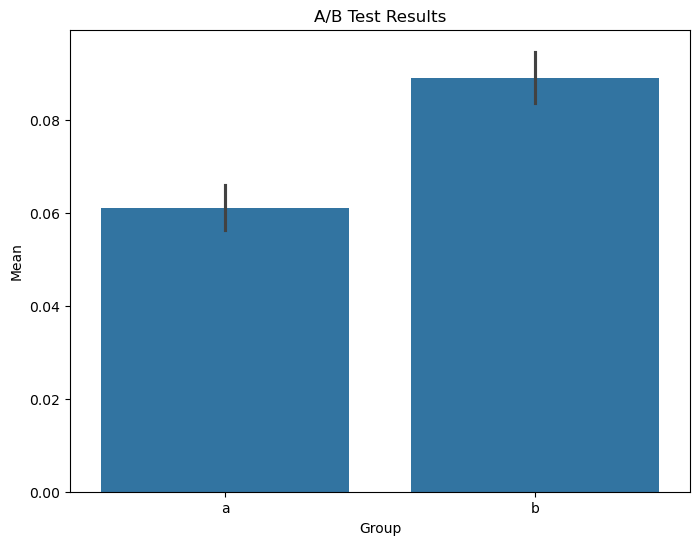

In [29]:
#Візуалізуємо порівняння середніх значень у групах з 95% довірчими інтервалами
plt.figure(figsize=(8, 6))
sns.barplot(x=df['test_group'], 
            y=df['conversion'], 
            errorbar=('ci', 95)) 

plt.title('A/B Test Results')
plt.xlabel('Group')
plt.ylabel('Mean')

plt.savefig('conversion_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


6. Висновок

У тестуванні взяли участь групи приблизно однакового розміру – 10013 осіб (контрольна) і 9985 (тестова).
Конверсія склала 6,1 і 8,9 відсотків відповідно.
Тест відбувався упродовж 21 дня, що дало змогу врахувати тижневу сезонність.
За результатами А/В тесту вищу конверсію показує група b – та, яка бачила екран з плашкою знижки. 
Значення статистики (z-test) -7.5197 вказує на суттєву різницю між показниками обох груп, тобто вона є статистично значущою.
Показник p-value, що становить значно менше за 0,05, вказує на те, що отримані дані з великою часткою ймовірності не є випадковими. 
Отже, нульову гіпотезу про відсутність відмінностей між групами можна відхилити.
Отримані результати дають підстави вважати, що впровадження нового екрана з плашкою знижки підвищить конверсію та матиме позитивний бізнес-ефект.